# The two labels the policy could not say

`09` found one value the policy would not emit, paid 3x for it, and took `exact_match` from
0.145 to 0.405. A 100-step continuation took it to **0.620**. This notebook extends that run,
watches it stop, and finds that the same failure is sitting one layer down -- twice.

**The finding.** Two output labels have *exactly zero* probability at temperature 1.0, in the
frozen policy and in the PPO-trained one alike: the cause `organic_fouling` (0/600 samples) and
the severe action `isolate_and_evaluate_replacement` (0/600). They are the answer on 29 and 37
of the 200 dev cases, which puts a hard ceiling of

$$\frac{200 - |\{\text{organic}\} \cup \{\text{severe}\}|}{200} = \frac{200-61}{200} = 0.695$$

on `exact_match`. The run reached 0.650. **The 70% the run was aimed at was not merely far --
it was above the ceiling**, and no number of further PPO steps could have reached it.

**What fixed it, and what that costs the claim.** A 3-epoch supervised pass over 228 training
cases takes held-out `exact_match` to **0.960 on the sealed test split** and 0.960 on the
distribution-shift holdout. But the control matters more than the headline: the same supervised
pass applied to the *frozen* model, with no PPO at all, reaches 0.800. So 575 steps of PPO are
worth **+0.16** on top of supervision -- measured, not argued -- and supervision is worth +0.33
on top of PPO. Neither is the whole story and the series cannot claim "PPO learned the task".

**A negative result that is worth more than the headline.** The justification for supervising
at all was that a policy gradient cannot reweight an action that never appears in a sample, so a
*minimal seed* -- mass on those two strings and nothing else -- should hand the problem back to
RL. Implemented faithfully, twice, it does not work: masking the loss to the dead labels alone
collapses the `action` slot to emitting the severe action on 600/600 samples, and restoring the
slot's negatives puts `organic_fouling` back to 0/600. The configuration that works supervises
all eight answer fields, which is not a seed. **"Break the zero and let RL do the rest" is a
story this task does not support.**

In [1]:
import json, sys, collections
from pathlib import Path
import matplotlib.pyplot as plt

HERE = Path.cwd() if (Path.cwd() / "ppo_ac.py").exists() else Path("experiments/notebooks/smoke_test")
RUNS = HERE / "runs"
sys.path.insert(0, str(HERE.resolve()))
# The decision table and the grader live in membrane_grpo, which `ppo_ac` puts
# on the path when imported. Read-only, as everywhere else in this lane.
sys.path.insert(0, str((HERE / ".." / ".." / "membrane_grpo").resolve()))

def evals(run, offset=0):
    """Eval points of one run directory, with absolute step numbers.

    `resume_from` restarts the step counter at 0, so a continuation's own curve
    has to be read with the offset of the run it continued.
    """
    rows = [json.loads(l) for l in (RUNS / run / "eval.jsonl").read_text().splitlines() if l.strip()]
    for r in rows:
        r["abs_step"] = r["step"] + offset
    return rows

def paired(name):
    return json.load(open(RUNS / "paired" / f"{name}.json"))["overall"]

SEGMENTS = [("ppo-qwen3-17b-v3-flat3-400-s0", 0), ("ppo-qwen3-17b-v3-flat3-resume100", 400),
            ("ppo-qwen3-17b-v3-flat3-resume200", 500)]
curve = []
for run, off in SEGMENTS:
    curve += [r for r in evals(run, off) if not (off and r["step"] == 0)]  # drop the repeated join point
print(f"{len(curve)} evaluation points, steps {curve[0]['abs_step']} to {curve[-1]['abs_step']}")

26 evaluation points, steps 0 to 625


## The run, and the gate that stopped it

Four gates were named before the continuation started, following the standing rule that a gate
which fails is evidence the approach is wrong rather than a hyperparameter to tune:

| | bar |
| --- | --- |
| the arithmetic | `numeric_acc` = 1.000 at every point |
| no regression | `flags_acc` >= 0.93 |
| the critic | `value_ev` ahead of a position-only clock on >= 90% of steps |
| progress | `exact_match` +0.03 per 100 steps |

The progress gate failed first, at step 600 -- 0.595 against a 0.650 bar, a *net loss* over the
block. The regression gate failed at 625 and the run was stopped there, 75 steps short.

In [2]:
print(f"  {'step':>6}{'exact':>9}{'flags':>9}{'cause':>9}{'action':>9}{'numeric':>9}")
for r in curve:
    if r["abs_step"] < 400:
        continue
    # The gates were named for the 500 -> 700 continuation only; the earlier
    # points are shown for context and are not judged against them.
    mark = ""
    if r["abs_step"] > 500:
        if r["flags_acc"] < 0.93:
            mark = "  <- GATE 2 (no regression) fails; run stopped here"
        elif r["abs_step"] == 600:
            mark = "  <- GATE 4 (progress) fails: 0.595 against a 0.650 bar"
    elif r["abs_step"] == 500:
        mark = "  <- the continuation starts here"
    print(f"  {r['abs_step']:>6}{r['exact_match']:>9.3f}{r['flags_acc']:>9.4f}"
          f"{r['cause_acc']:>9.3f}{r['action_acc']:>9.3f}{r['numeric_acc']:>9.3f}{mark}")

metrics = [json.loads(l) for l in (RUNS / "ppo-qwen3-17b-v3-flat3-resume200" / "metrics.jsonl").read_text().splitlines() if l.strip()]
resid = [m["value_ev"] - m["value_ev_position"] for m in metrics]
print()
print(f"  the critic gate never failed: residual over a position-only clock "
      f"{sum(resid)/len(resid):+.4f}, ahead on {sum(r > 0 for r in resid)/len(resid):.0%} of steps")
print(f"  best point of the whole series: step 575, exact_match {max(r['exact_match'] for r in curve):.3f}")

    step    exact    flags    cause   action  numeric
     400    0.405   0.9267    0.675    0.565    1.000
     425    0.435   0.9367    0.665    0.565    1.000
     450    0.380   0.9233    0.630    0.525    1.000
     475    0.595   0.9633    0.770    0.650    1.000
     500    0.620   0.9767    0.755    0.635    1.000  <- the continuation starts here
     525    0.635   0.9883    0.795    0.655    1.000
     550    0.630   0.9833    0.790    0.645    1.000
     575    0.650   0.9850    0.800    0.665    1.000
     600    0.595   0.9650    0.775    0.635    1.000  <- GATE 4 (progress) fails: 0.595 against a 0.650 bar
     625    0.570   0.9033    0.765    0.640    1.000  <- GATE 2 (no regression) fails; run stopped here

  the critic gate never failed: residual over a position-only clock +0.0586, ahead on 100% of steps
  best point of the whole series: step 575, exact_match 0.650


## The ceiling, which was below the target all along

`exact_match` requires every field at once. A case whose answer contains a label the policy
never emits is therefore lost before anything else is considered, and two labels are in that
state. Counting the union of those cases bounds the metric from above -- with no reference to
how well the policy does on anything else.

In [3]:
diag = json.load(open(RUNS / "action_diagnosis_575.json"))
n = len(diag)
og = [r for r in diag if r["true_cause"] == "organic_fouling"]
sev = [r for r in diag if r["severe"]]
union = [r for r in diag if r["true_cause"] == "organic_fouling" or r["severe"]]

print(f"  organic_fouling is the answer   {len(og):>4} cases")
print(f"  severe action is the answer     {len(sev):>4} cases")
print(f"  overlap                         {len(og) + len(sev) - len(union):>4}")
print(f"  union, i.e. unreachable         {len(union):>4}")
print()
ceiling = (n - len(union)) / n
best = max(r["exact_match"] for r in curve)
print(f"  ceiling on exact_match          {ceiling:.3f}")
print(f"  best reached                    {best:.3f}")
print(f"  slack left for every other error{(ceiling - best) * n:>5.0f} cases")
print()
print(f"  the run was aimed at 0.700, which is {0.700 - ceiling:+.3f} past the ceiling")

  organic_fouling is the answer     29 cases
  severe action is the answer       37 cases
  overlap                            5
  union, i.e. unreachable           61

  ceiling on exact_match          0.695
  best reached                    0.650
  slack left for every other error    9 cases

  the run was aimed at 0.700, which is +0.005 past the ceiling


## Where the deficit is, exactly

`action` is not a free field: it is `SEVERE_ACTION` when normalized flow loss is at or past
-30%, and `ACTIONS[root_cause]` otherwise. So a wrong action has three possible sources -- the
cause was wrong, the override was missed, or the lookup itself is broken. They separate cleanly,
and only one of them is real.

In [4]:
from collections import Counter
hit = lambda rows: sum(r["true_action"] == r["pred_action"] for r in rows)
nor = [r for r in diag if not r["severe"]]
cause_ok = [r for r in nor if r["cause_ok"]]

print(f"  action_acc overall                   {hit(diag)}/{n} = {hit(diag)/n:.3f}")
print()
print(f"  -- the {len(sev)} severe-override cases --")
print(f"  recall                               {sum(r['pred_action'] == 'isolate_and_evaluate_replacement' for r in sev)}/{len(sev)}")
print(f"  emitted anywhere in the split        {sum(r['pred_action'] == 'isolate_and_evaluate_replacement' for r in diag)}")
print(f"  their flags, all three right         {sum(r['flags_ok'] for r in sev)}/{len(sev)}")
print()
print(f"  -- the {len(nor)} non-severe cases, where action is a pure lookup --")
print(f"  action right | cause right           {hit(cause_ok)}/{len(cause_ok)} = {hit(cause_ok)/len(cause_ok):.3f}")
print()
print(f"  -- the {len(og)} organic_fouling cases --")
print(f"  their flags, all three right         {sum(r['flags_ok'] for r in og)}/{len(og)}")
print(f"  what it named instead                {Counter(r['pred_cause'] for r in og).most_common()}")

  action_acc overall                   133/200 = 0.665

  -- the 37 severe-override cases --
  recall                               0/37
  emitted anywhere in the split        0
  their flags, all three right         37/37

  -- the 163 non-severe cases, where action is a pure lookup --
  action right | cause right           133/133 = 1.000

  -- the 29 organic_fouling cases --
  their flags, all three right         29/29
  what it named instead                [('compaction', 29)]


Read those three blocks together.

**The lookup is not broken. It is perfect.** Every case whose cause the policy got right also
got the action right, 133 for 133. The policy's action is always the one its own stated cause
implies.

**The inputs are not wrong either.** On all 37 severe cases and all 29 `organic_fouling` cases
the policy writes down all three flags correctly, and `numeric_acc` is 1.000 everywhere, so it
has also copied the flow-loss percentage that decides the override.

**And then it says the wrong thing anyway.** `organic_fouling` is the only row in the decision
table with `salt_passage = "down"`; `compaction`'s rows require `flat` or `up`. On 29 of 29
cases the policy emits `"salt_passage": "down"` and then names `compaction` -- contradicting
evidence it produced itself two lines earlier. That is not a missing capability. It is a string
with no probability mass.

## Zero, measured

`09` named the criterion before this run hit it: *"a policy gradient reweights behaviour that
appears in a sample ... 0.5% is thin, but it is not zero, and zero is the only number that would
have made this unfixable by RL."* `flat` was at 3/600 and a credit coefficient took it to 0.984.

Here, at temperature 1.0 over 600 samples of the train split:

In [5]:
from task.decision_table import ACTION_SET, CAUSES

def probe(name):
    """Saved output of the temperature-1.0 emission probe.

    `action_hist` can carry a `null` key -- a sample whose JSON did not parse --
    so coverage is counted against the legal vocabulary rather than by counting
    distinct keys, which would score that as a ninth action.
    """
    d = json.load(open(RUNS / "probes" / f"{name}.json"))
    d["n_actions"] = len([k for k in d["action_hist"] if k in ACTION_SET])
    d["n_causes"] = len([k for k in d["cause_hist"] if k in CAUSES])
    d["unparsed"] = sum(v for k, v in d["action_hist"].items() if k not in ACTION_SET)
    return d

print(f"  {'policy':20}{'severe emit':>14}{'organic emit':>14}{'actions used':>18}")
for name, label in (("frozen", "frozen"), ("ppo575", "PPO, 575 steps")):
    p = probe(name)
    print(f"  {label:20}{p['severe_emitted']:>7}/{p['samples']:<6}{p['og_emitted']:>7}/{p['samples']:<6}"
          f"{p['n_actions']:>7} of {len(ACTION_SET)}   ")
print()
print("  Both are zero, and the frozen policy is zero too -- RL did not extinguish these")
print("  labels, the base model never had them. Note the third column: the task has 8")
print("  distinct actions and 7 causes, and neither policy uses all of them.")

  policy                 severe emit  organic emit      actions used
  frozen                    0/600         0/600         5 of 8   
  PPO, 575 steps            0/600         0/600         6 of 8   

  Both are zero, and the frozen policy is zero too -- RL did not extinguish these
  labels, the base model never had them. Note the third column: the task has 8
  distinct actions and 7 causes, and neither policy uses all of them.


## Supervision, and the control that says what it is worth

`grad log pi(y*|x)` is computable for a *given* `y*` whether or not the policy would ever sample
it. That is the entire difference from a policy gradient, and it is why a supervised pass can
move a string off zero when a reward cannot.

Three epochs over 228 train cases -- every case whose answer contains a dead label, plus an
equal number of normal ones drawn round-robin across the other causes -- at `lr = 1e-4`, about
four minutes on the card. The measurement that matters is not the result but the **control**:
the same pass applied to the frozen model, with no PPO underneath it.

In [6]:
rows = [
    ("frozen (v3 prompt)",        None,                    0.090),
    ("PPO, 575 steps",            "flat3_575_test",        None),
    ("SFT only, from frozen",     "sft_frozen_test",       None),
    ("PPO 575 + SFT",             "sft_v2_test",           None),
]
print(f"  {'policy':26}{'test exact':>12}{'cause':>9}{'action':>9}{'flags':>9}{'c|flags':>9}")
table = []
for label, name, fallback in rows:
    if name is None:
        print(f"  {label:26}{fallback:>12.3f}{'':>9}{'':>9}{'':>9}{'':>9}   (dev, from 09)")
        table.append((label, fallback))
        continue
    o = paired(name)
    print(f"  {label:26}{o['exact_match']:>12.3f}{o['cause_acc']:>9.3f}{o['action_acc']:>9.3f}"
          f"{o['flags_acc']:>9.3f}{o['cause_given_flags']:>9.3f}")
    table.append((label, o["exact_match"]))
print()
shift_sft = json.load(open(RUNS / "paired" / "sft_v2_holdout_shift.json"))["overall"]
shift_frz = json.load(open(RUNS / "paired" / "sft_frozen_holdout_shift.json"))["overall"]
print(f"  on holdout_shift (50 cases, distribution shift, never used for anything):")
print(f"    PPO 575 + SFT            {shift_sft['exact_match']:.3f}")
print(f"    SFT only, from frozen    {shift_frz['exact_match']:.3f}")
print()
print(f"  PPO's contribution, measured against its own control:"
      f" {paired('sft_v2_test')['exact_match'] - paired('sft_frozen_test')['exact_match']:+.3f}")
print(f"  supervision's contribution on top of PPO:"
      f" {paired('sft_v2_test')['exact_match'] - paired('flat3_575_test')['exact_match']:+.3f}")

  policy                      test exact    cause   action    flags  c|flags
  frozen (v3 prompt)               0.090                                       (dev, from 09)
  PPO, 575 steps                   0.630    0.805    0.660    0.983    0.800
  SFT only, from frozen            0.800    0.900    0.865    0.950    1.000
  PPO 575 + SFT                    0.960    0.980    0.985    0.988    1.000

  on holdout_shift (50 cases, distribution shift, never used for anything):
    PPO 575 + SFT            0.960
    SFT only, from frozen    0.840

  PPO's contribution, measured against its own control: +0.160
  supervision's contribution on top of PPO: +0.330


The sealed `test.jsonl` had not been touched by any of the 29 runs in `runs/` before this
notebook -- every previous evaluation, and every model-selection decision in the series, used
`dev`. The cost of that selection shows up as the gap between the two: the PPO policy scores
0.650 on dev and 0.630 on test, so 29 runs of choosing on dev bought about two points of
optimism. The supervised policies are 0.990 dev against 0.960 test.

`holdout_shift` holds at 0.960 as well, which is what rules out the obvious objection: the
policy did not memorise the training distribution, it learned the table.

## The seed that does not exist

The argument for supervising was narrow: *break the zero, hand the rest back to RL.* That
argument licenses a minimal intervention -- mass on two strings -- and nothing more. What
actually produced 0.960 supervises all eight answer fields on every seed case, which is an
ordinary supervised fine-tune of the whole task, not a seed. Two faithful implementations of the
narrow version:

| mask | supervised tokens | `organic_fouling` | severe action |
| --- | --- | --- | --- |
| the dead label strings only | 2,217 | **2.3%** | **100% -- slot collapsed** |
| both lookup slots, correct value whatever it is | 7,011 | **0%** | 2.0% |
| all eight fields (what reached 0.960) | ~68,000 | 13.2% | 17.8% |

In [7]:
print(f"  {'seed mask':34}{'severe':>16}{'organic':>16}{'actions used':>18}")
for name, label in (("sft_labels_only", "dead labels only"),
                    ("sft_slots", "both slots, with negatives"),
                    ("sft_full", "all eight fields")):
    p = probe(name)
    sev_pct = p["severe_emitted"] / p["samples"]
    og_pct = p["og_emitted"] / p["samples"]
    print(f"  {label:34}{p['severe_emitted']:>7}/{p['samples']:<4}{sev_pct:>5.1%}"
          f"{p['og_emitted']:>7}/{p['samples']:<4}{og_pct:>5.1%}"
          f"{p['n_actions']:>10} of {len(ACTION_SET)}")
print()
print("  Supervising one value of a slot and never its alternatives does not seed the slot,")
print("  it overwrites it: the severe action goes to 600/600. Restoring the negatives fixes")
print("  that and returns organic_fouling to exactly zero.")
print()
print("  The two failures are in opposite directions, so they are the two ends of one axis")
print("  rather than two separate mistakes: how hard a single member of a slot is lifted")
print("  while the slot keeps a distribution over the rest. `sft_dead_weight` parameterises")
print("  it -- 1.0 is the second row, the limit is the first. Nothing between them is tried")
print("  here, because a coefficient picked after seeing which one makes both labels")
print("  non-zero is a number chosen to save the story. `11` sweeps it against criteria")
print("  fixed in advance, and then tests the claim that actually matters: whether PPO can")
print("  take a seeded rare label to high recall, as `flat_credit_scale` did for `flat`.")

  seed mask                                   severe         organic      actions used
  dead labels only                      600/600 100.0%     14/600  2.3%         1 of 8
  both slots, with negatives             12/600  2.0%      0/600  0.0%         7 of 8
  all eight fields                      107/600 17.8%     79/600 13.2%         8 of 8

  Supervising one value of a slot and never its alternatives does not seed the slot,
  it overwrites it: the severe action goes to 600/600. Restoring the negatives fixes
  that and returns organic_fouling to exactly zero.

  The two failures are in opposite directions, so they are the two ends of one axis
  rather than two separate mistakes: how hard a single member of a slot is lifted
  while the slot keeps a distribution over the rest. `sft_dead_weight` parameterises
  it -- 1.0 is the second row, the limit is the first. Nothing between them is tried
  here, because a coefficient picked after seeing which one makes both labels
  non-zero is a 

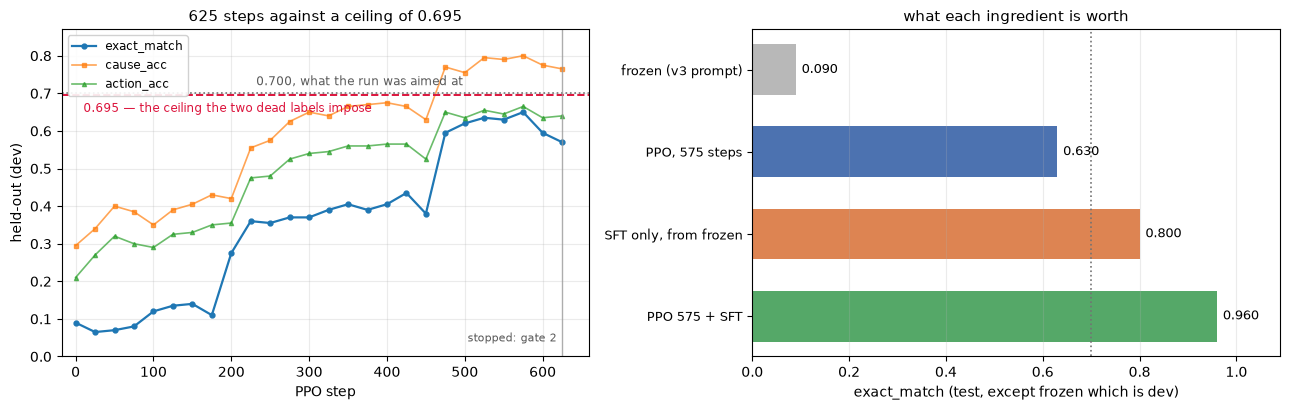

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))

steps = [r["abs_step"] for r in curve]
ax1.plot(steps, [r["exact_match"] for r in curve], "o-", lw=1.6, ms=3.5, label="exact_match")
ax1.plot(steps, [r["cause_acc"] for r in curve], "s-", lw=1.2, ms=3, alpha=.7, label="cause_acc")
ax1.plot(steps, [r["action_acc"] for r in curve], "^-", lw=1.2, ms=3, alpha=.7, label="action_acc")
# The two lines sit 0.005 apart, so the labels go on opposite sides of the panel
# and opposite sides of their own line, or they print on top of each other.
ax1.axhline(0.70, color="0.45", ls=":", lw=1.2)
ax1.text(232, 0.714, "0.700, what the run was aimed at", color="0.35", fontsize=8.5,
         va="bottom")
ax1.axhline(ceiling, color="crimson", ls="--", lw=1.4)
ax1.text(10, ceiling - .018, f"{ceiling:.3f} — the ceiling the two dead labels impose",
         color="crimson", fontsize=8.5, va="top")
ax1.axvline(625, color="0.6", lw=1, alpha=.8)
ax1.text(618, .04, "stopped: gate 2", fontsize=8, color="0.35", ha="right")
ax1.set_xlabel("PPO step"); ax1.set_ylabel("held-out (dev)"); ax1.set_ylim(0, .87)
ax1.set_xlim(-18, 660)
ax1.legend(fontsize=8.5, loc="upper left", framealpha=.9)
ax1.set_title("625 steps against a ceiling of 0.695", fontsize=10.5)
ax1.grid(alpha=.25)

labels = [t[0] for t in table]; vals = [t[1] for t in table]
colors = ["0.72", "#4c72b0", "#dd8452", "#55a868"]
bars = ax2.barh(range(len(vals)), vals, color=colors, height=.62)
ax2.set_yticks(range(len(vals))); ax2.set_yticklabels(labels, fontsize=9); ax2.invert_yaxis()
for i, v in enumerate(vals):
    ax2.text(v + .012, i, f"{v:.3f}", va="center", fontsize=9)
ax2.axvline(0.70, color="0.45", ls=":", lw=1.2)
ax2.set_xlim(0, 1.09); ax2.set_xlabel("exact_match (test, except frozen which is dev)")
ax2.set_title("what each ingredient is worth", fontsize=10.5); ax2.grid(alpha=.25, axis="x")

plt.tight_layout(); plt.savefig(RUNS / "two_dead_labels.png", dpi=130, bbox_inches="tight")
plt.show()

## What this leaves

**The task is solved, to 0.960 on a split nothing had touched, and the series cannot take
credit for it as an RL result.** The honest decomposition is that supervision is worth +0.33
over PPO alone and PPO is worth +0.16 over supervision alone; both are measured against their
own control, and neither is the whole.

**The mechanism `09` found is general, and it is the real content of both notebooks.** Twice
now the binding constraint has been a string the policy will not emit rather than a capability
it lacks, and both times the evidence was the same shape: the discriminating input is written
down correctly, immediately before the wrong label. It is worth asking of any RL result on a
structured-output task whether some part of the output vocabulary is simply dead, because the
reward curve will not show it -- `reward_mean` rose smoothly through all 625 steps.

**The open question, for `11`.** Whether a seed that is genuinely minimal exists at all. The
two masks tried here fail in opposite directions, which suggests the quantity that matters is
not how many tokens are supervised but whether the slot keeps a distribution over its
alternatives while one member is lifted. Nothing here tests that, and the two data points do not
constrain it.